![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/visual-nlp-workshop/blob/master/jupyter/SparkOcrWSIDeidentification.ipynb)

## Whole Slide Imaging De-identification

In this notebook, we will explore how to handle the de-identification of Whole Slide Imaging (WSI) files, specifically focusing on SVS files.</br>
We will cover:
* Removal of auxiliary images, like macro and label images.
* Removal of Metadata.
* Main image cleaning: in this situation we don't want to remove the entire image like the case of for example macro or label images, but we want to remove only specific regions which contain PHI. We want to do this keeping the quality of the original image intact. This process involves the following steps which we will discuss in next sections,
  * Extract Tiles from SVS
  * Deidentify Tiles
  * Update the original source SVS file to mask tiles containing PHI.

Let's jump right in!

### Introduction to the SVS file format

The SVS file format (commonly used for whole slide images (WSI) in digital pathology) is based on the TIFF format and supports multi-resolution (pyramidal) image storage. It allows storing extremely large images efficiently, along with metadata and multiple resolutions for fast zooming and viewing.
SVS typically stores images in a pyramid of resolutions,
* level 0 -> full resolution.
* level 1 -> downsampled version, like 1/4 of the resolution at level 0.
* ...
* level N -> more downsampling.

Something like this(image taken from nema.org),</br>
![sample wsi](https://dicom.nema.org/dicom/dicomwsi/sup145_fromword_files/image008.gif)

At each level, images are not stored as a single monolithic unit, but as a set of _tiles_. This enables for a more efficient handling of the image by viewers.</br>
We'll see how we can exploit this characteristic to process the images in parallel and in the most efficient manner.

### Real World Example

In [ ]:
secret = ""
license = ""
aws_access_key = ""
aws_secret_key = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12"

### Initialization of spark session

In [1]:
from sparkocr import start
import os
import sys

if license:
    os.environ['JSL_OCR_LICENSE'] = license
    os.environ['SPARK_NLP_LICENSE'] = license

if aws_access_key:
    os.environ['AWS_ACCESS_KEY'] = aws_access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key

nlp_secret = ""

spark = start(secret=secret,
              jar_path=spark_ocr_jar_path, nlp_internal=True, nlp_secret=nlp_secret)

spark

### Removal of auxiliary images, like macro and label images, along with metadata.
First things first, before diving into the full resolution images, let's see how to remove the auxiliary images and the metadata. For this, the `svs.remove_phi()` comes handy. Let's take a look at the documentation,

In [1]:
from sparkocr.utils.svs.phi_cleaning import remove_phi
help(remove_phi)

Help on function remove_phi in module sparkocr.utils.svs.phi_cleaning:

remove_phi(input, output, tags=['ImageDescription.Filename', 'ImageDescription.Date', 'ImageDescription.Time', 'ImageDescription.User'], append_tags=[], rename=False, verbose=False, blocking=True)
    Remove label images, macro images, and specified metadata from SVS files.
    
    This function processes SVS files to remove sensitive metadata and associated images.
    By default, it removes specific metadata tags: "ImageDescription.Filename",
    "ImageDescription.Date", "ImageDescription.Time", and "ImageDescription.User".
    
    Parameters:
    - input (str): The file path or directory containing the SVS files to be de-identified.
    - output (str): The file path or directory where the de-identified files will be saved.
    - tags (list, optional): A list of metadata tags to remove, replacing the default tags if provided.
    - append_tags (list, optional): Additional tags to remove, added to the defaults w

So we see from the documentation that we can remove label, and macro images along with a predefined set of metadata tags. We can also add our own custom list of tags.</br>
We have everything we need, so let's do it!,

In [2]:
# make sure input files are in this folder
input_path = './data/svs/62893.svs'
output_path = "deid_svs"

remove_phi(input_path, output_path, verbose=True)

de-identifying ./data/svs/62893.svs
no need to clean: label
no need to clean: macro
Copied ./data/svs/62893.svs as deid_svs/62893.svs


<Thread(Thread-6 (copy_and_strip_all), stopped 140534193583680)>

#### [optional] Tweaking additional parameters
You can safely skip this if you are good with the set of metadata tags that were removed.

In [3]:
input_path = './data/svs/62893.svs'
output_path = "svs_output"

remove_phi(input_path, output_path, verbose=True, append_tags=['ImageDescription.ScanScope ID', 'ImageDescription.Time Zone', 'ImageDescription.ScannerType'])

de-identifying ./data/svs/62893.svs
no need to clean: label
no need to clean: macro
Copied ./data/svs/62893.svs as svs_output/62893.svs


<Thread(Thread-7 (copy_and_strip_all), stopped 140534193583680)>

#### Cleaning of the main image
Here we will de-identify the main image. We start by pulling the tiles out of the SVS.

In [4]:
!mkdir tiles_output
OUTPUT_FOLDER = "tiles_output/"

In [5]:
from sparkocr.utils.svs.tile_extraction import svs_to_tiles

# level=0 only because the text in this sample is very small; for real slides set level="auto"
svs_to_tiles(input_path, OUTPUT_FOLDER, level=0)

Processing file: 62893.svs
No thumbnail page in 62893.svs, skipping it.


#### Text Detection

In [6]:
import matplotlib.pyplot as plt

from sparknlp.annotator import *
from sparknlp.base import *
import sparknlp_jsl
from sparknlp_jsl.annotator import *

import sparkocr
from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import display_image, display_images, to_pil_image

09:48:45, INFO generated new fontManager


In [7]:
# Repeating the definition here for this path
temp_tile_output = "./tiles_output/62893/selected"
image_df = spark.read.format("binaryFile").load(temp_tile_output)

At this point, `image_df` has all the tiles, from every level in the source SVS file. Next thing we need to do is to try to detect text and PHI in those tiles.</br>
Let's define the pipeline steps we need to accomplish this.

In [8]:
bin_to_image = BinaryToImage() \
    .setInputCol("content") \
    .setOutputCol("image_raw") \
    .setImageType(ImageType.TYPE_BYTE_GRAY) \
    .setKeepInput(False)

text_detector = ImageTextDetector.pretrained("image_text_detector_mem_opt", "en", "clinical/ocr") \
    .setInputCol("image_raw") \
    .setOutputCol("text_regions") \
    .setScoreThreshold(0.7) \
    .setLinkThreshold(0.5) \
    .setWithRefiner(True) \
    .setTextThreshold(0.4) \
    .setSizeThreshold(-1) \
    .setUseGPU(False) \
    .setWidth(0) \
    .setHeight(0)

new_stages = [
    bin_to_image,
    text_detector
]

svs_text_detection = PipelineModel(stages=new_stages)

image_text_detector_mem_opt download started this may take some time.


Approximate size to download 77.5 MB
image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


Download done! Loading the resource.


In [9]:
result = svs_text_detection.transform(image_df)

In [10]:
df_tile = result.select("text_regions", "exception")

In [11]:
result.select("text_regions", "exception").show(5, False)

2026-09-30 09:48:54.528055024 [W:onnxruntime:ort-java, device_discovery.cc:211 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:91 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


+--------------------------------------------------------------------------------------------------------------------------+---------+
|text_regions                                                                                                              |exception|
+--------------------------------------------------------------------------------------------------------------------------+---------+
|[]                                                                                                                        |null     |
|[{0, 0, 976.0, 286.0, 108.0, 92.0, 0.8117647, V1, 90.0, true}]                                                            |null     |
|[]                                                                                                                        |null     |
|[{0, 0, 298.0, 204.0, 40.0, 52.0, 0.8156863, V1, 90.0, true}, {0, 0, 254.0, 208.0, 40.0, 52.0, 0.7529412, V1, 90.0, true}]|null     |
|[{0, 0, 165.0, 407.0, 78.0, 90.0, 0.74509805, V1, 90.0

**NOTE**: Here we can see the different tiles and the text that was detected on each of them. You can filter the tiles with detected text and use it as input for deid pipeline, other tiles won't be fed into the pipeline, so that we don't waste resources analyzing them.

#### Inspect target images
Let's look into some of the images containing text,


    Image #0:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T4.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


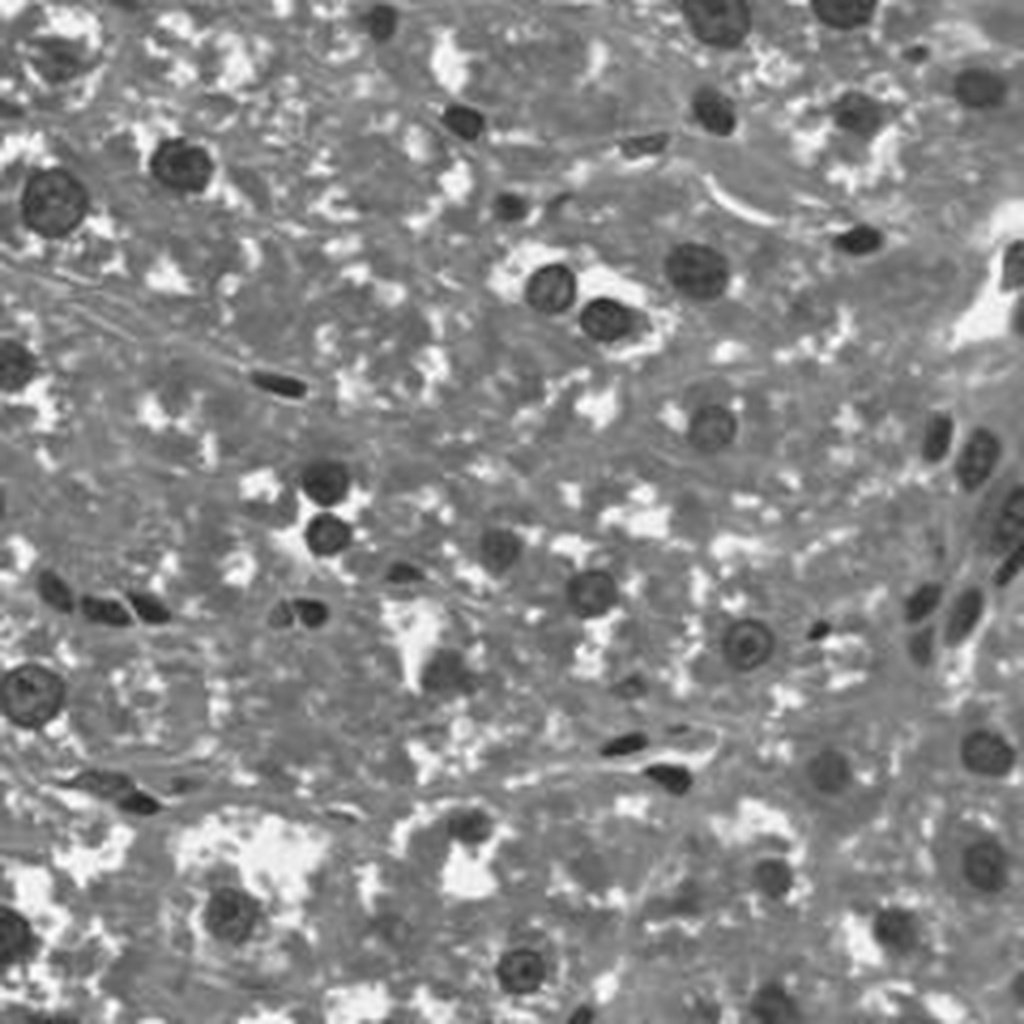


    Image #1:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T5.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


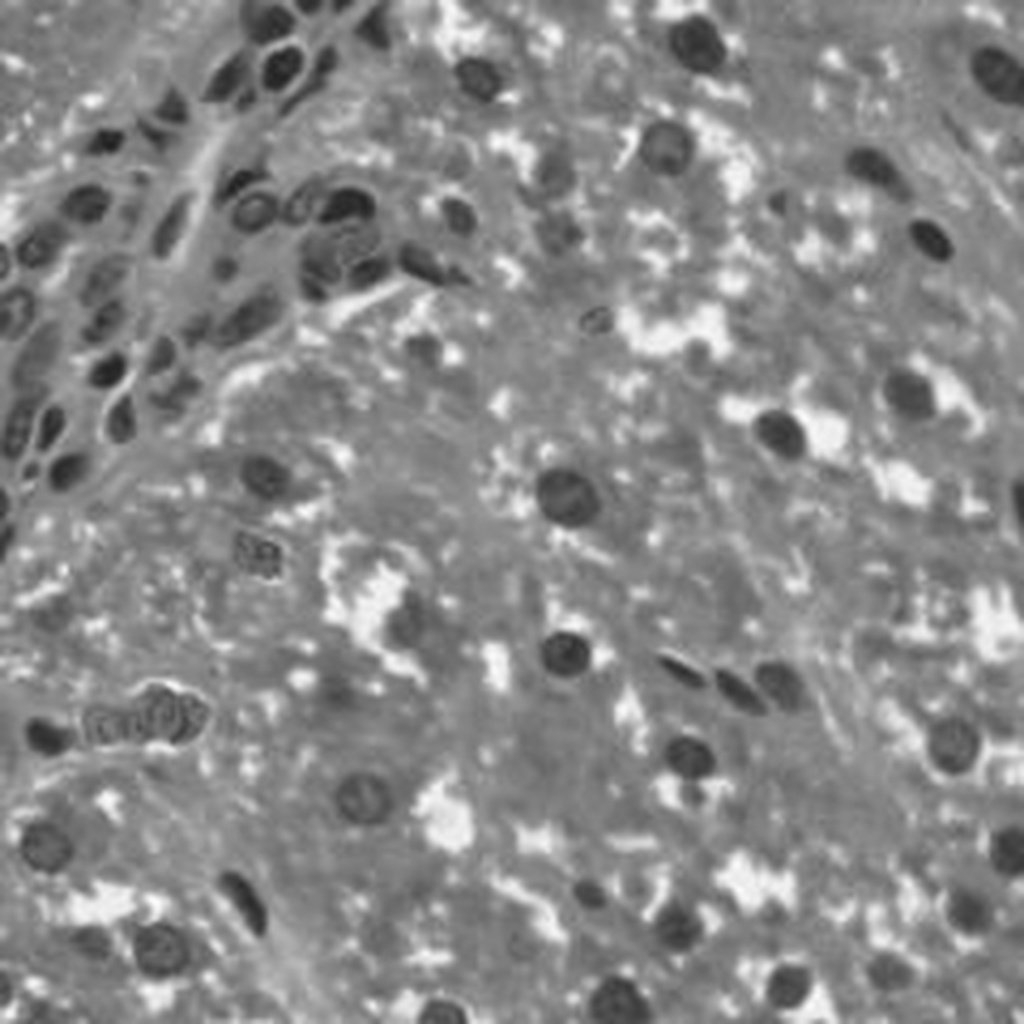


    Image #2:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T6.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


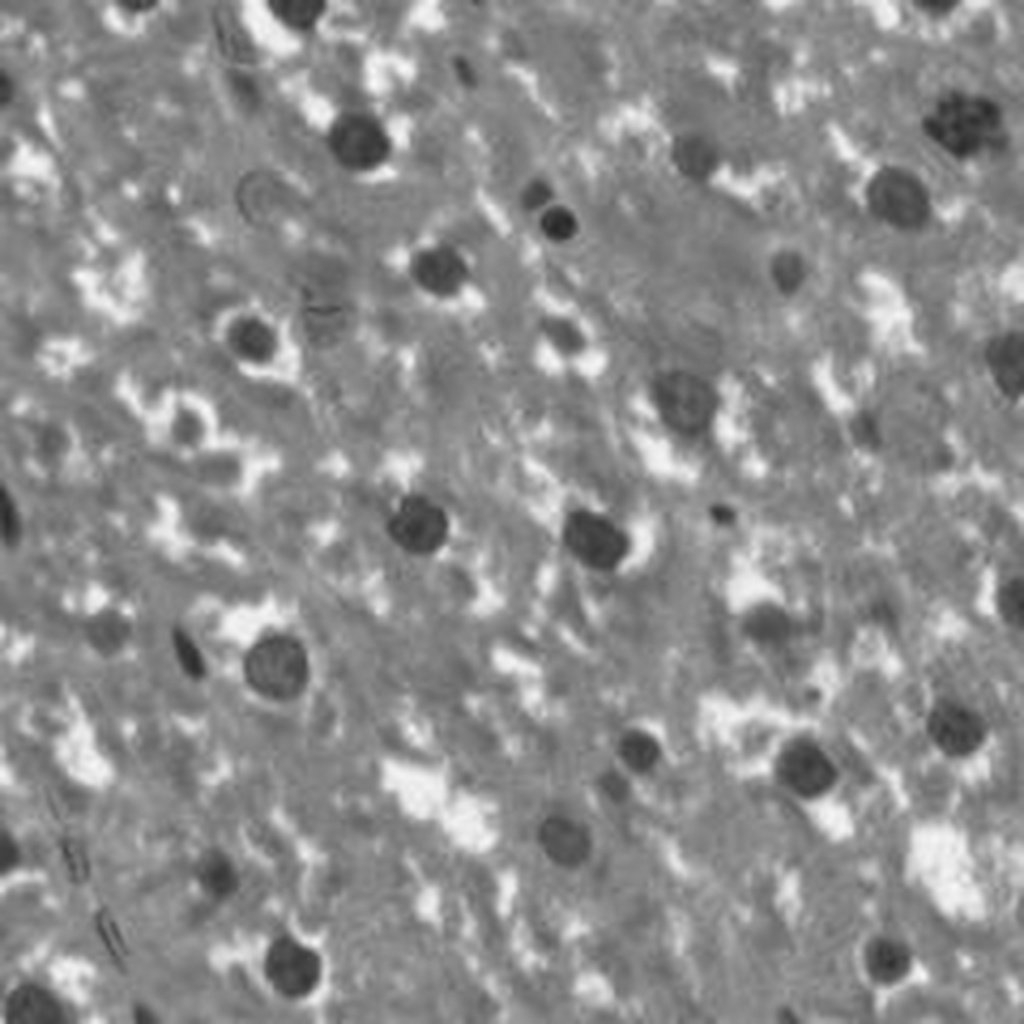


    Image #3:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T30.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


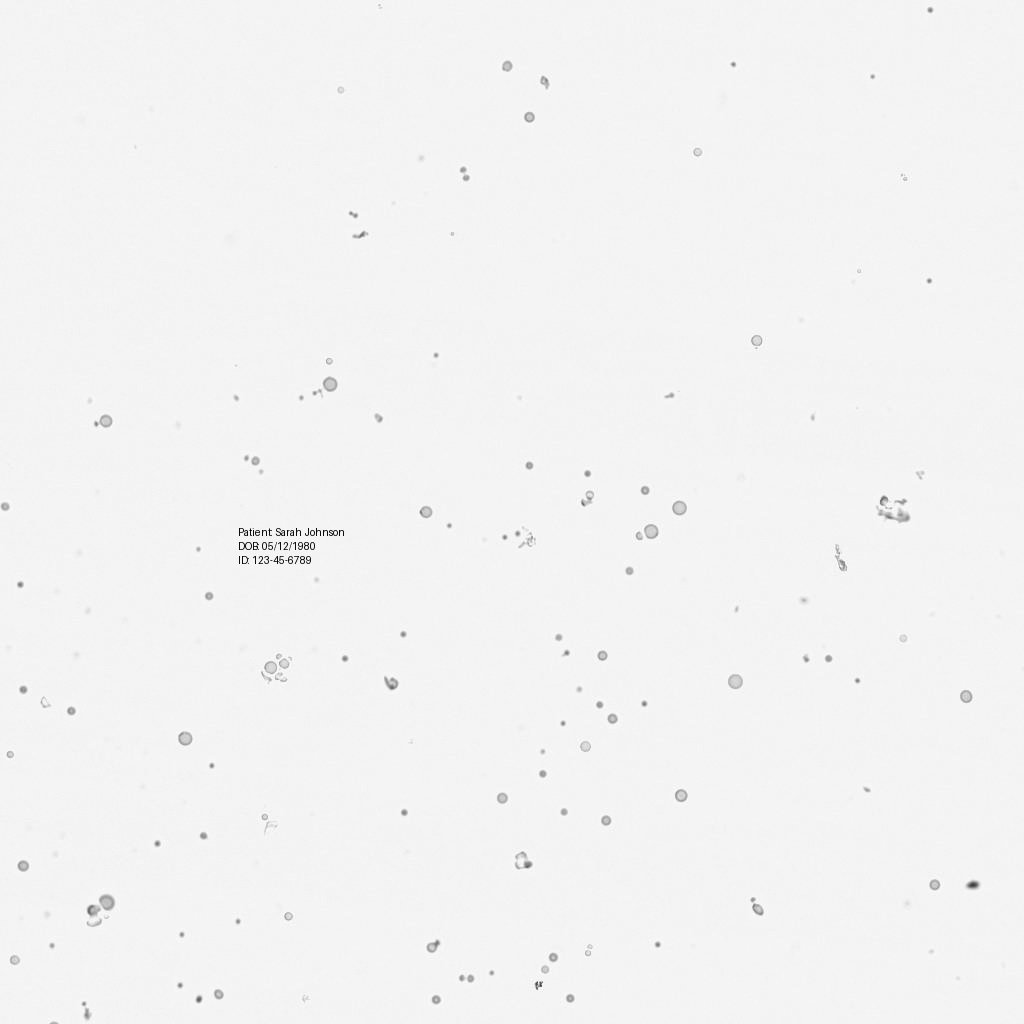


    Image #4:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T31.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


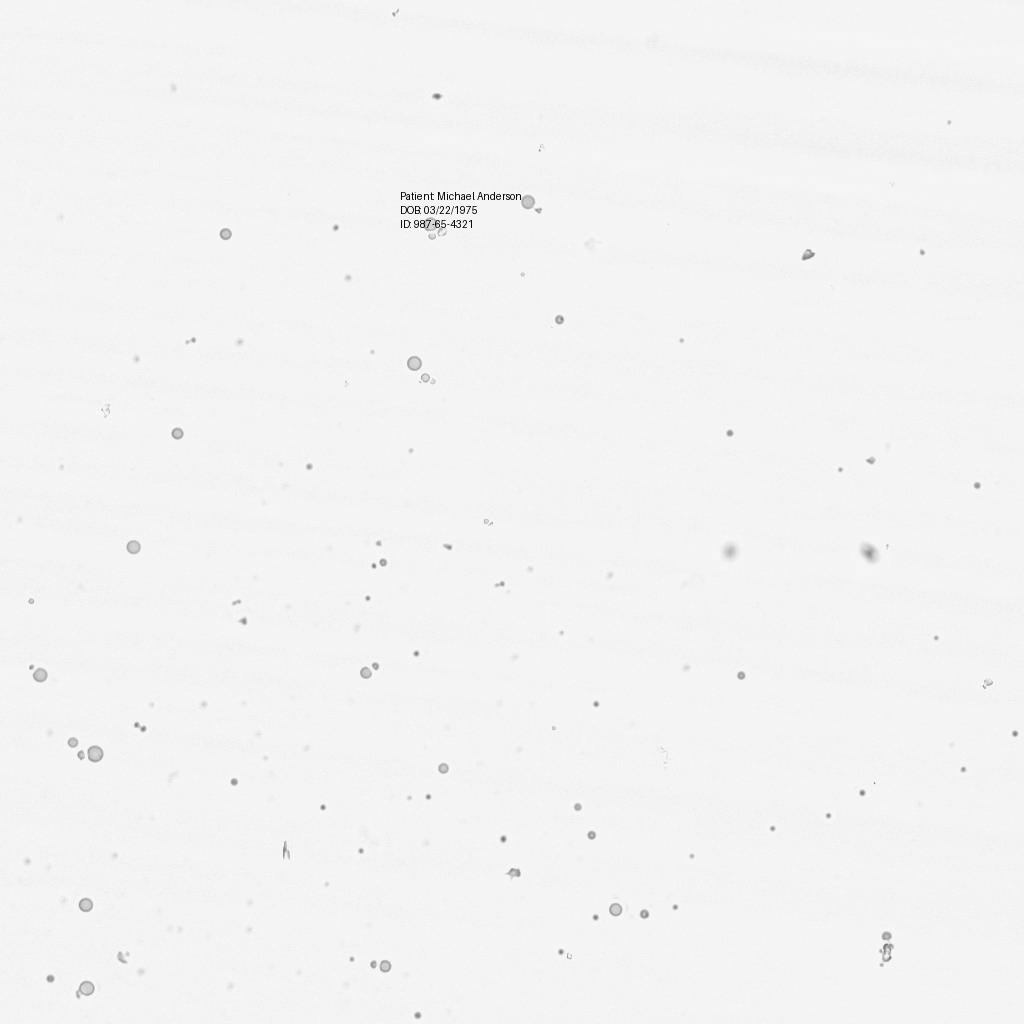

In [12]:
from pyspark.sql.functions import size

result = result.filter(size(result["text_regions"]) > 0).cache()
display_images(result, "image_raw")

#### PHI removal per-se

In [13]:
from sparkocr.pretrained import PretrainedPipeline
deid_pipeline = PretrainedPipeline("image_deid_multi_model_context_pipeline_cpu", "en", "clinical/ocr")

image_deid_multi_model_context_pipeline_cpu download started this may take some time.


Approx size to download 4.9 GB
[ | ]

image_deid_multi_model_context_pipeline_cpu download started this may take some time.
Approximate size to download 4.9 GB


Download done! Loading the resource.


[ / ]

...

[ / ]

[ — ]

[ \ ]

[ | ]

[OK!]

### Run pipeline

In [14]:
# we already have detected text, remove text detector
deid_pipeline.model.stages = deid_pipeline.model.stages[1:]
result_deid = deid_pipeline.transform(result)
deid_info = result_deid.select("path", "coordinates").distinct()

In [15]:
deid_info.distinct().show(5, False)

Using CPUs


Using CPUs


26/09/30 09:52:09 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.


+-------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|path                                                         |coordinates                                                                                                                                                                                                                    |
+-------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T4.jpg |[{0, 0, 930.0, 232.0, 92.0, 108.0, 0.0, Coordinate, 0.0, false}]         

#### [optional] Cache regions using parquet
We can cache the regions in disk, to avoid potential re-computation and to be able to recover in case of failure.

In [16]:
deid_info.repartition(10).write.format("parquet").mode("overwrite").save("./cached_regions.parquet")

26/09/30 09:52:26 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.


In [17]:
deid_info = spark.read.parquet("./cached_regions.parquet").repartition(10)

#### Display deid tile
Let's take a look at the result of this process

26/09/30 09:52:35 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.



    Image #0:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T4.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


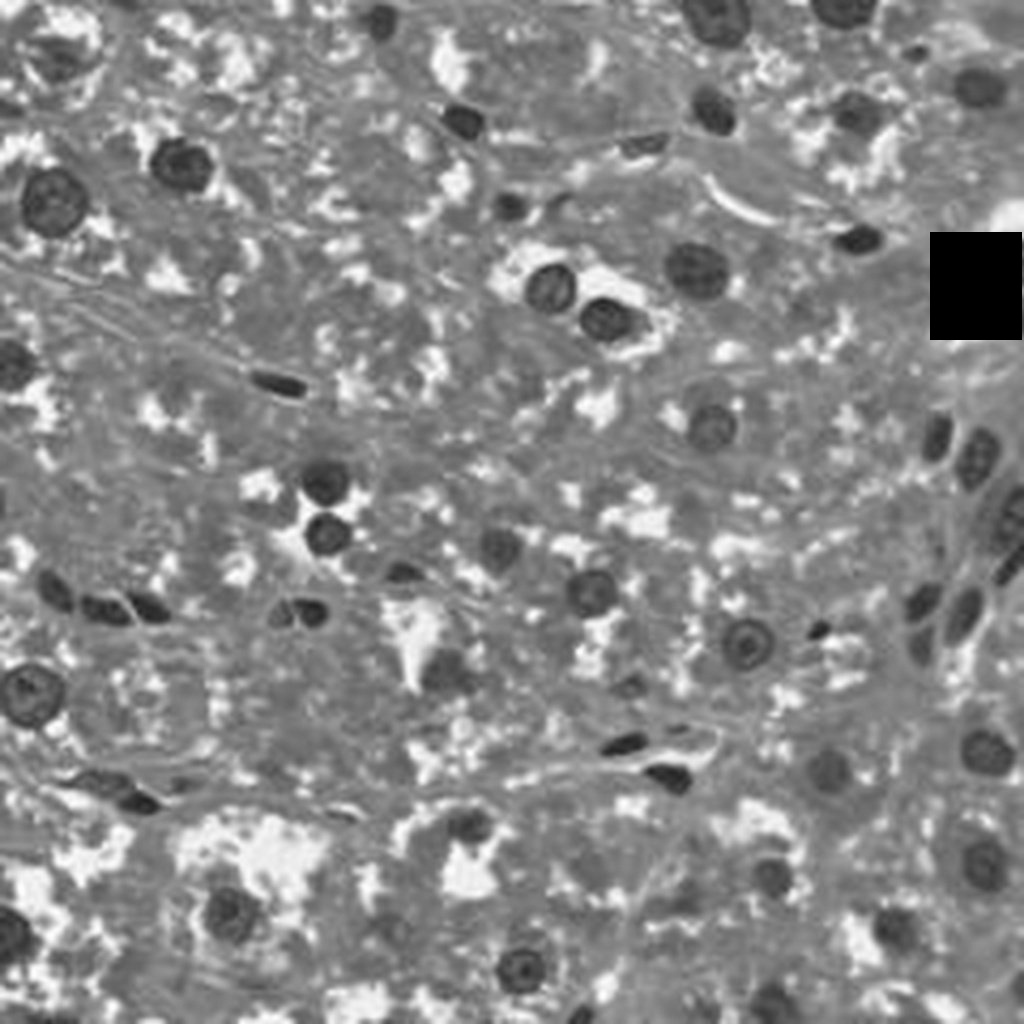


    Image #1:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T5.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


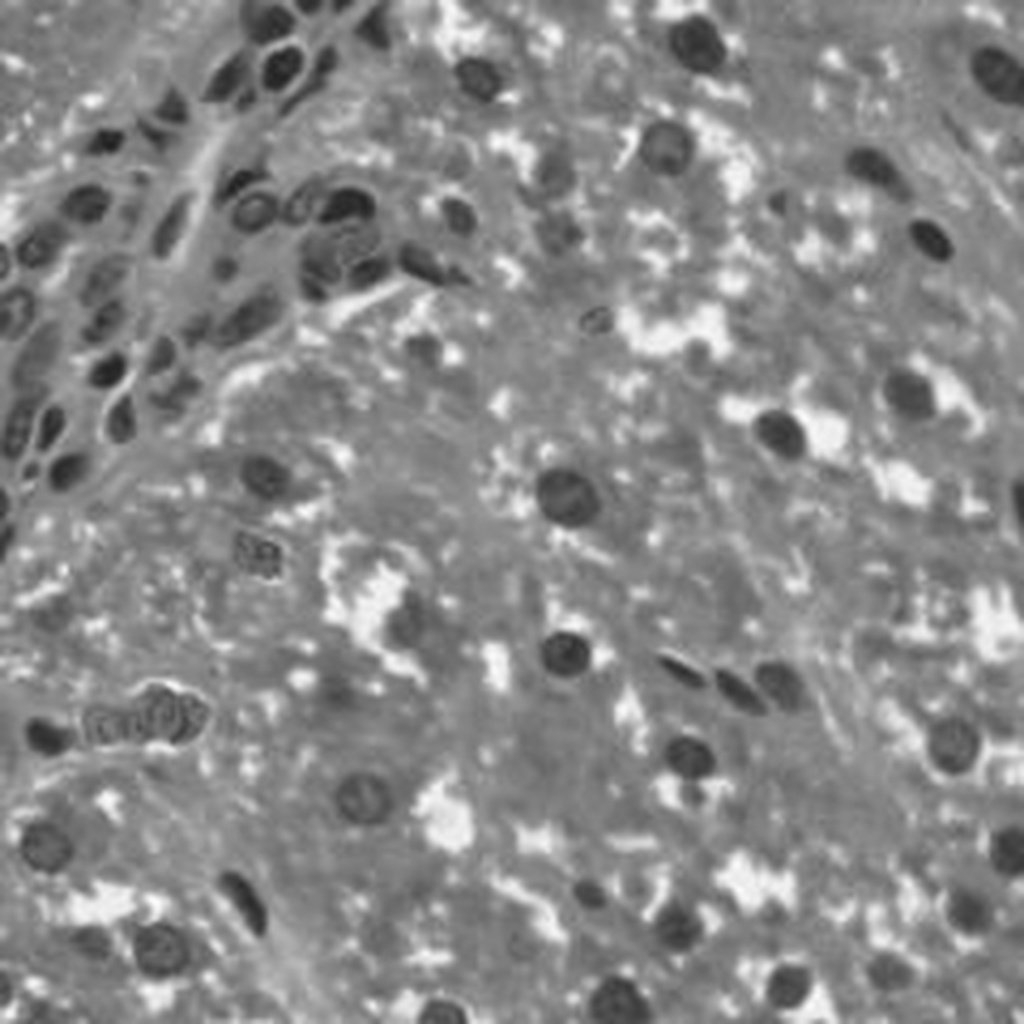


    Image #2:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T6.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


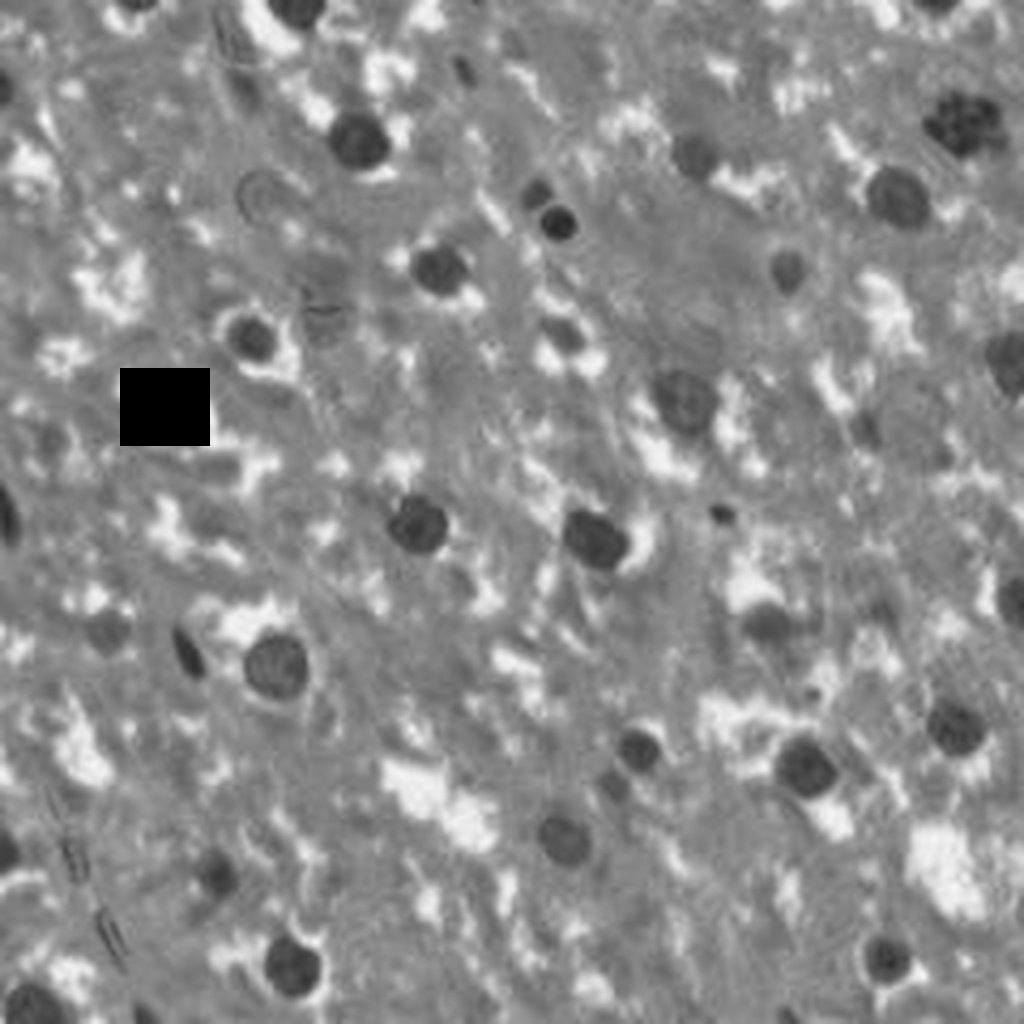


    Image #3:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T30.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


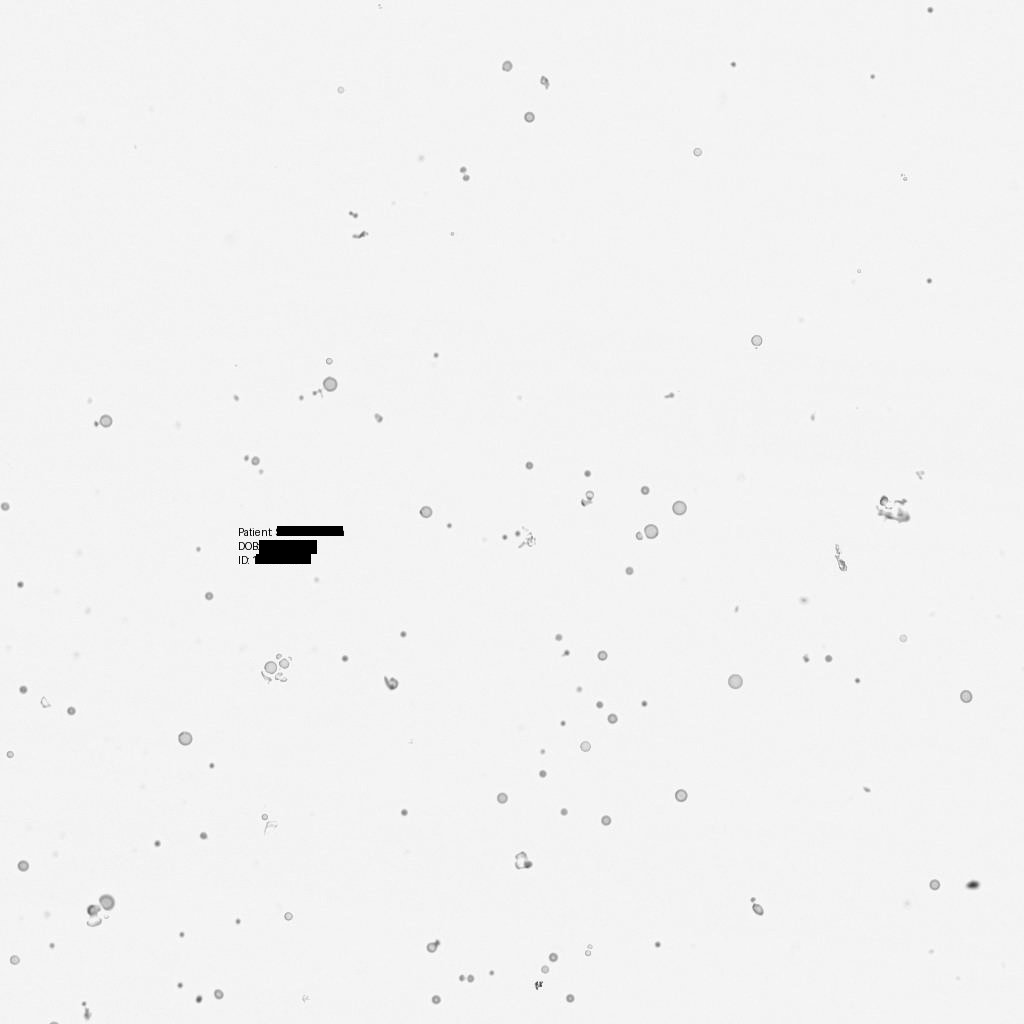


    Image #4:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T31.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


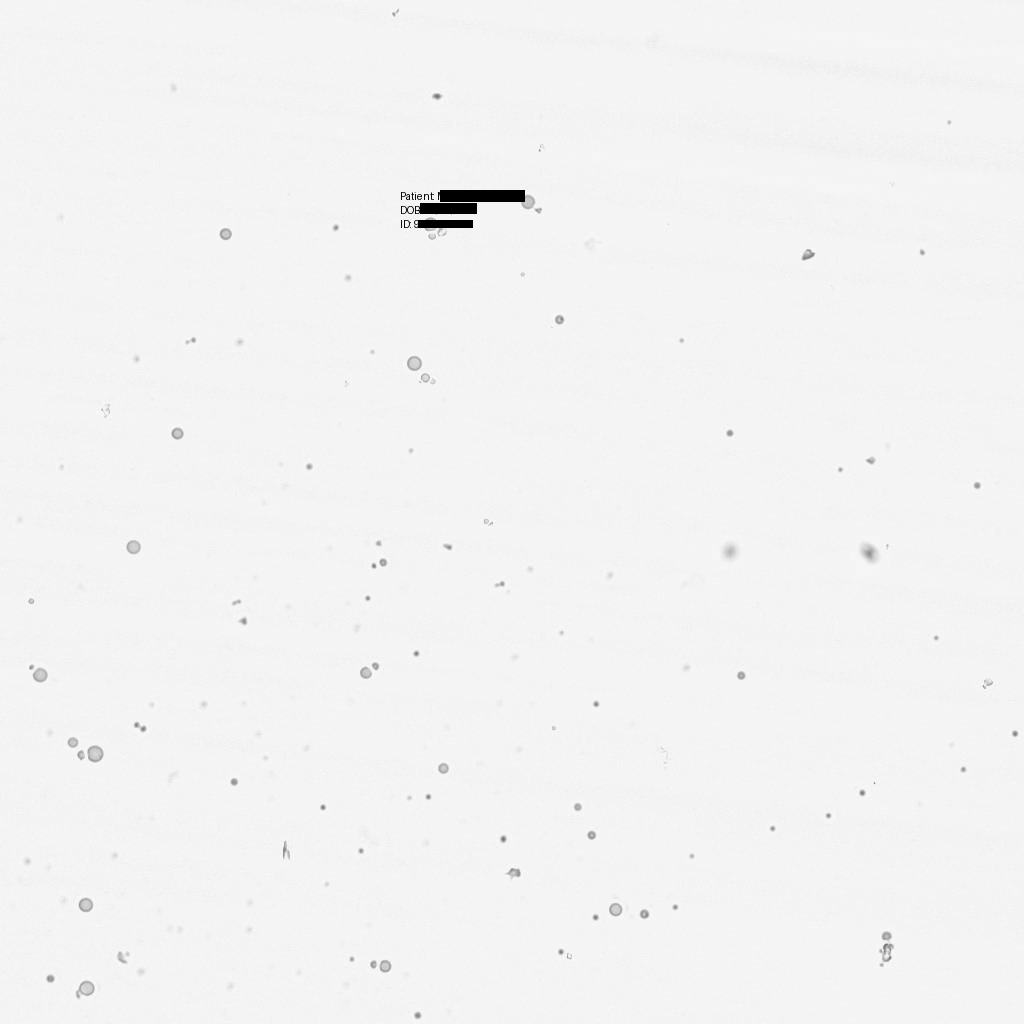

In [18]:
from sparkocr.utils import display_images
display_images(result_deid, "image_with_regions")

#### [optional] Alternative NLP pipeline
You can plug a play different NLP pipelines, consider taking a look at models on our models hub.

In [19]:
import matplotlib.pyplot as plt

from sparknlp.annotator import *
from sparknlp.base import *
import sparknlp_jsl
from sparknlp_jsl.annotator import *

import sparkocr
from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import display_image, to_pil_image
from sparknlp.pretrained import PretrainedPipeline

In [20]:
deid_pipeline = PretrainedPipeline("ner_deid_context_augmented_pipeline", "en", "clinical/models")
stages = deid_pipeline.model.stages[0:7]

ocr = ImageToTextV2.pretrained("ocr_base_printed_v2_opt", "en", "clinical/ocr") \
    .setRegionsColumn("text_regions") \
    .setInputCols(["image_raw"]) \
    .setOutputCol("text") \
    .setOutputFormat("text_with_positions") \
    .setGroupImages(False) \
    .setKeepInput(True) \
    .setUseGPU(False) \
    .setUseCaching(True) \
    .setBatchSize(4)

stages.insert(0,ocr)

custom_ner_converter_internal = NerConverterInternalModel() \
        .setInputCols(["sentence", "token", "ner_subentity"]) \
        .setOutputCol("ner_chunk_subentity") \
        .setThreshold(0.7) \
        .setWhiteList(['NAME', 'AGE', 'CONTACT', 'LOCATION', 'PERSON', 'DATE', 'IDNUM', 'DOCTOR', 'PATIENT', 'MEDICALRECORD', 'PHONE', 'CITY','ZIP'])

stages.append(custom_ner_converter_internal)

position_finder = PositionFinder() \
    .setInputCols("ner_chunk_subentity") \
    .setOutputCol("coordinates") \
    .setPageMatrixCol("positions") \
    .setOcrScaleFactor(0.9)

drawRegions = ImageDrawRegions()  \
    .setInputCol("image_raw")  \
    .setInputRegionsCol("coordinates")  \
    .setOutputCol("image_with_regions")  \
    .setFilledRect(True) \
    .setRectColor(Color.gray)

stages.append(position_finder)
stages.append(drawRegions)
pipeline = Pipeline(stages=stages)

ner_deid_context_augmented_pipeline download started this may take some time.


Approx size to download 1.6 GB
[ | ]

ner_deid_context_augmented_pipeline download started this may take some time.
Approximate size to download 1.6 GB


Download done! Loading the resource.


[ / ]

[ — ]

[OK!]

ocr_base_printed_v2_opt download started this may take some time.
Approximate size to download 433 MB


Download done! Loading the resource.


In [21]:
result_deid = pipeline.fit(result).transform(result)
deid_info = result_deid.select("path", "coordinates").distinct()

In [22]:
deid_info.distinct().show(5, False)

26/09/30 09:52:55 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.


26/09/30 09:52:55 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.
26/09/30 09:52:55 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.


+-------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------+
|path                                                         |coordinates                                                                                                                                             |
+-------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------+
|file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T4.jpg |[]                                                                                                                                                      |
|file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T6.jpg |[]                                                                   

In [23]:
deid_info.repartition(10).write.format("parquet").mode("overwrite").save("./cached_regions.parquet")

26/09/30 09:53:01 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.


26/09/30 09:53:02 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.
26/09/30 09:53:02 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.


In [24]:
deid_info = spark.read.parquet("./cached_regions.parquet").repartition(10)

26/09/30 09:53:05 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.


26/09/30 09:53:12 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.
26/09/30 09:53:12 ERROR ImageDrawRegions: Invalid or empty `coordinates`: Ensure it is non-empty and contains valid data.



    Image #0:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T4.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


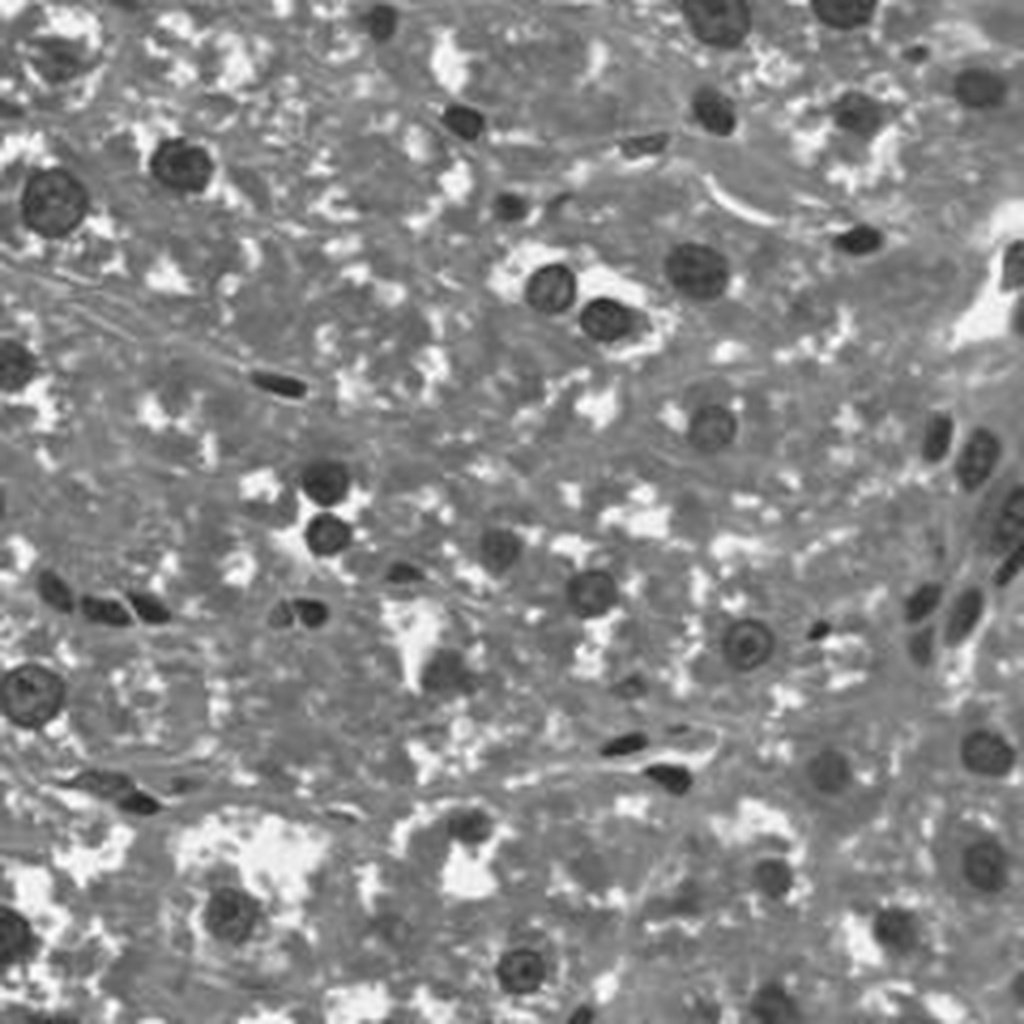


    Image #1:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T5.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


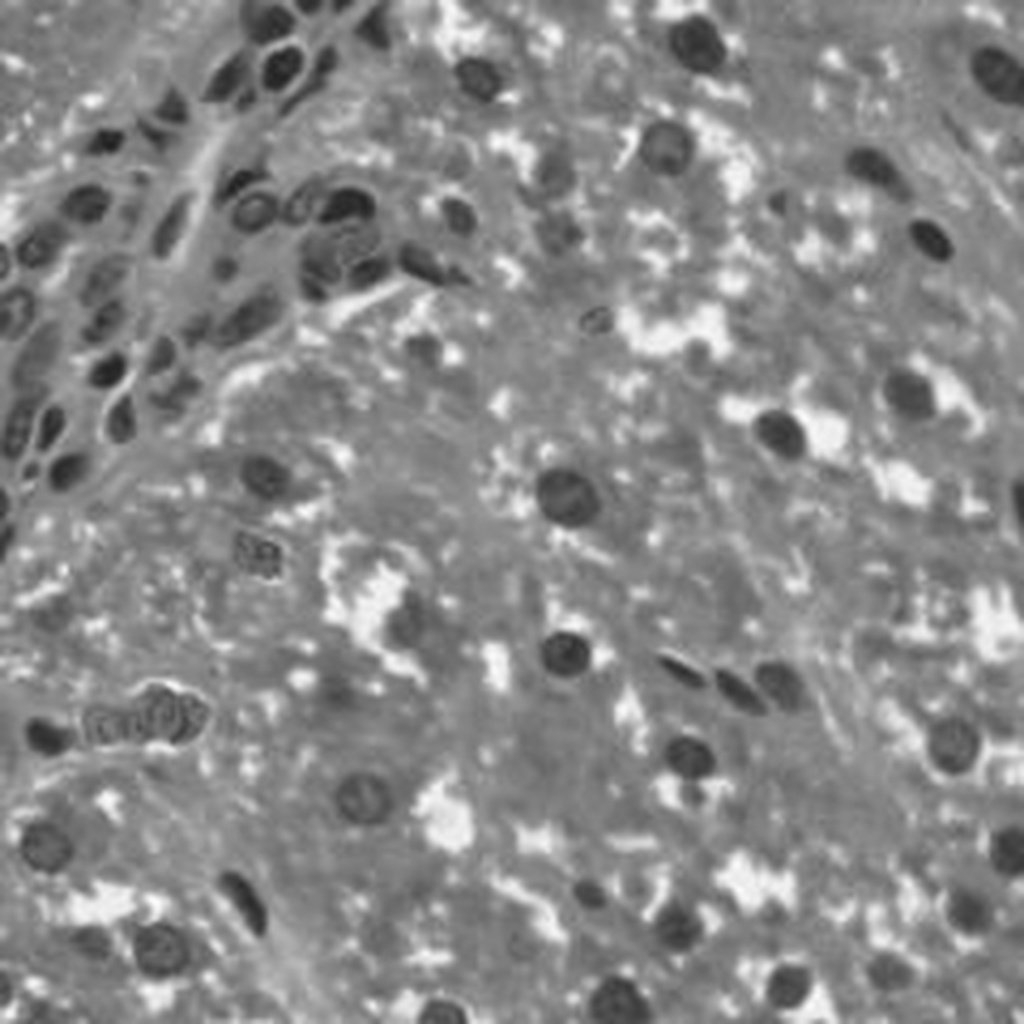


    Image #2:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T6.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


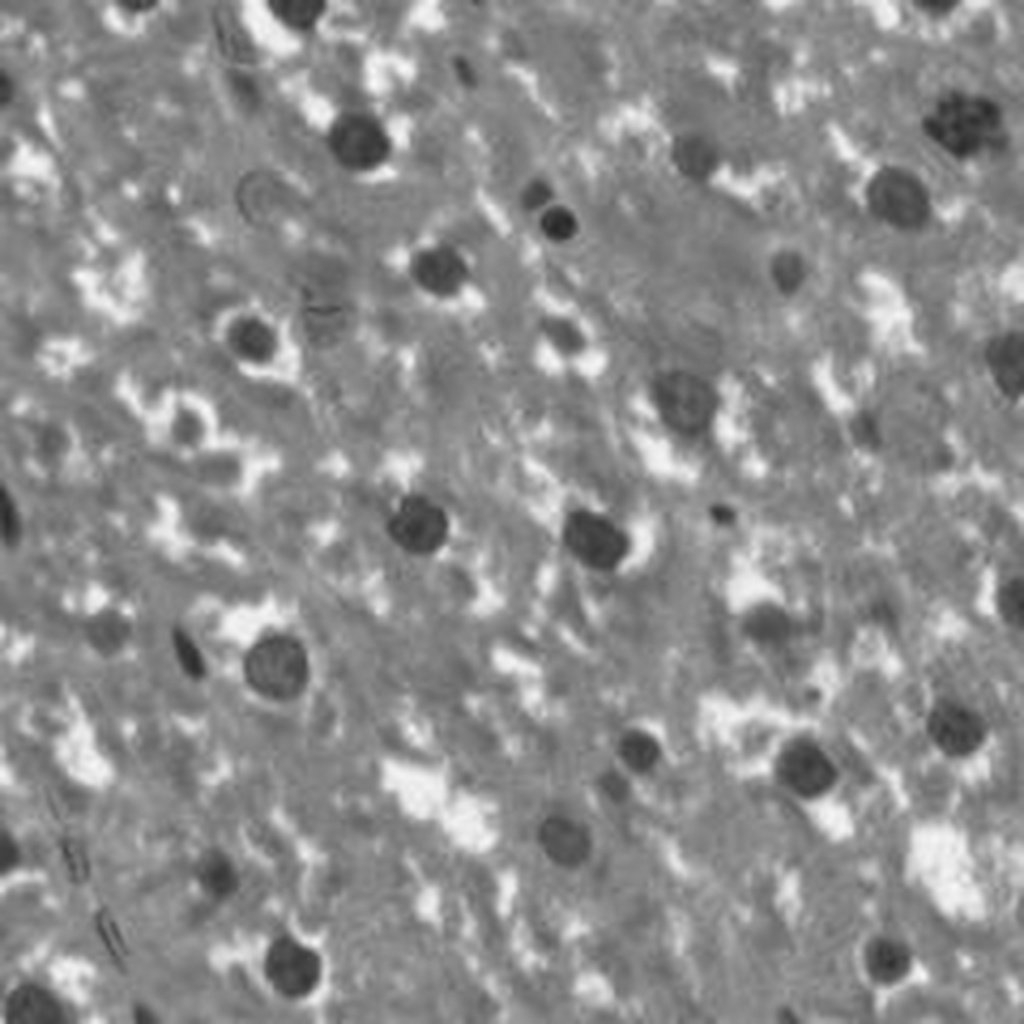


    Image #3:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T30.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


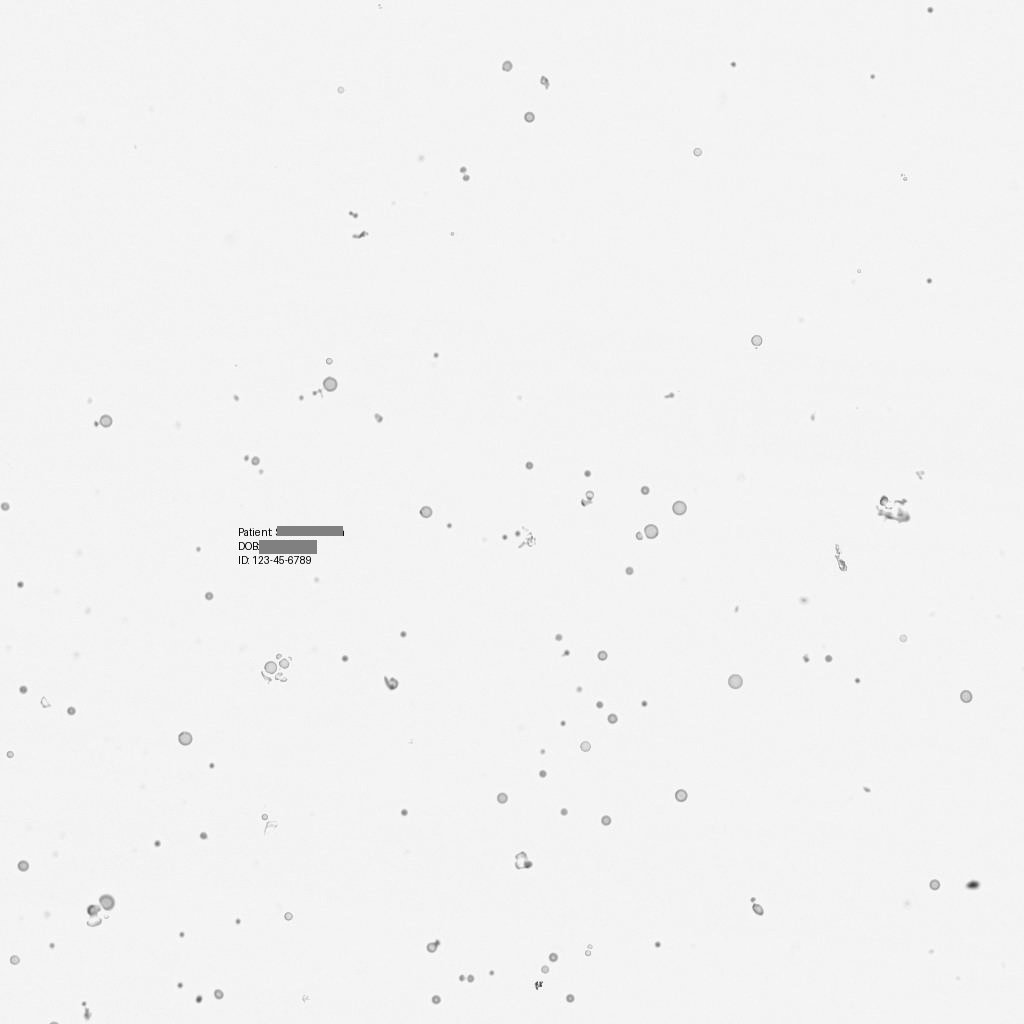


    Image #4:
    Origin: file:/nb/jupyter/tiles_output/62893/selected/62893_L0_T31.jpg
    Resolution: 0 dpi
    Width: 1024 px
    Height: 1024 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


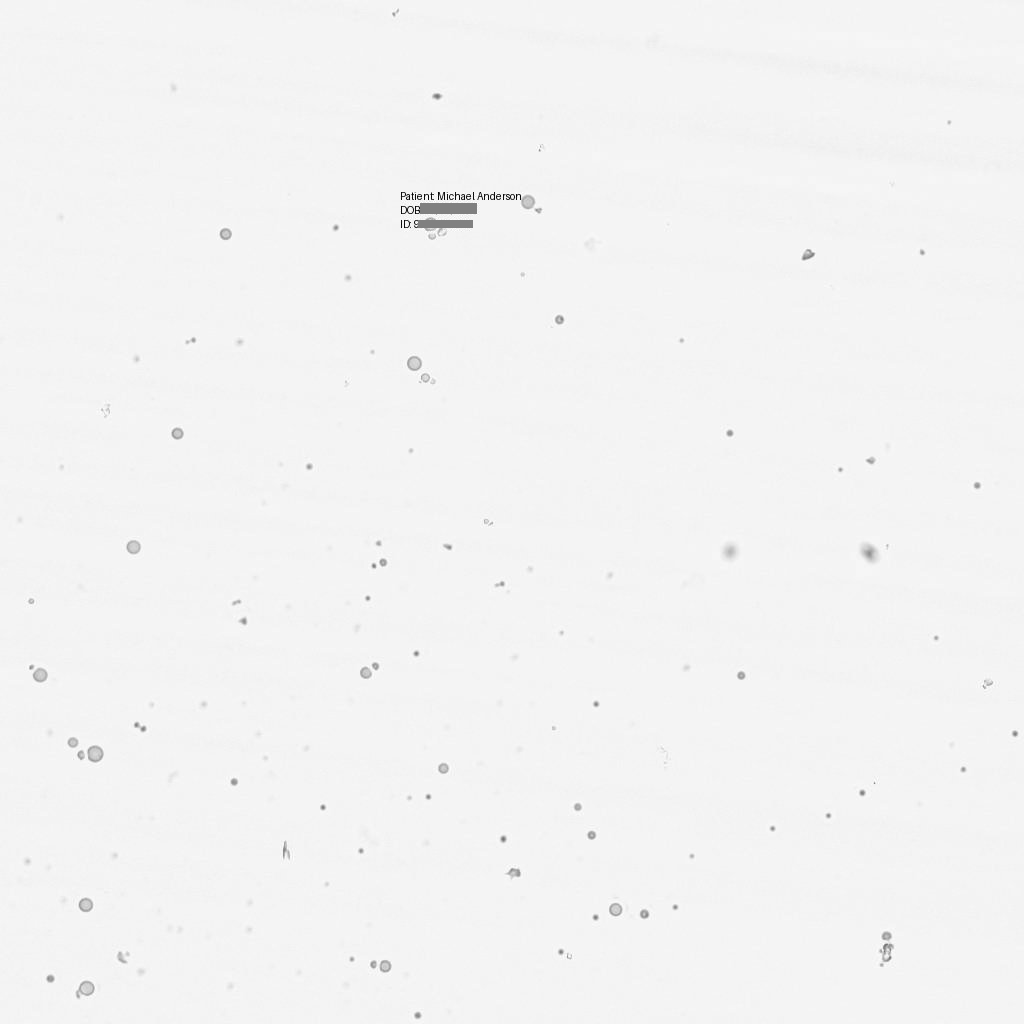

In [25]:
display_images(result_deid, "image_with_regions")

#### Masking of specific tiles in the SVS
This is our final step!. We will mask the specific tiles in the source SVS using the regions we obtained during previous steps.</br>
First, let's create a copy of our files.

In [26]:
!cp -r "$output_path" deid_svs_copy
svs_path_out = "svs_deid/"

In [27]:
from sparkocr.utils.svs.phi_redaction import redact_phi_in_tiles

redact_phi_in_tiles("deid_svs_copy", deid_info, OUTPUT_FOLDER, output_svs_path=svs_path_out, create_new_svs_file = True)

09:53:17, INFO Processing group 1/1 (1 files)


Group 1/1:   0%|          | 0/1 [00:00<?, ?file/s]

Group 1/1: 100%|██████████| 1/1 [00:00<00:00, 11.70file/s]

09:53:17, INFO Starting deidentification on SVS: deid_svs_copy/62893.svs


09:53:17, INFO Total pages in SVS: 2


### Mode 2: blanket de-identification
Instead of running the PHI pipeline, every text region found by the text detector is redacted. No de-identification pipeline is loaded, so it only needs the Spark session started above.

In [28]:
from sparkocr.utils.svs.deidentify import deidentify_svs

deidentify_svs("./data/svs/62893.svs", "deid_svs_blanket/62893.svs", mode="blanket")

Processing file: 62893.svs
No thumbnail page in 62893.svs, skipping it.
image_text_detector_mem_opt download started this may take some time.


Approximate size to download 77.5 MB


09:53:30, INFO Starting deidentification on SVS: /tmp/svs_deid_ejxdlkj0/cleaned/62893.svs


09:53:30, INFO Total pages in SVS: 2


'deid_svs_blanket/62893.svs'